In [1]:
import numpy as np
import math

In [2]:
def get_named_beta_schedule(schedule_name, num_diffusion_timesteps):
    
    if schedule_name == "linear":
        
        scale = 1000 / num_diffusion_timesteps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        return np.linspace(
            beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64
        )
    
    elif schedule_name == "cosine":

        return betas_for_alpha_bar(
            num_diffusion_timesteps,
            lambda t: math.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2,
        )
    
    else:

        raise NotImplementedError(f"unknown beta schedule: {schedule_name}")
    

def betas_for_alpha_bar(num_diffusion_timesteps, alpha_bar, max_beta=0.999):
    
    betas = []

    for i in range(num_diffusion_timesteps):

        t1 = i / num_diffusion_timesteps
        t2 = (i + 1) / num_diffusion_timesteps
        betas.append(min(1 - alpha_bar(t2) / alpha_bar(t1), max_beta))

    return np.array(betas)

In [3]:
betas = get_named_beta_schedule('cosine', 500)

In [4]:
alphas = 1. - betas

In [5]:
alphas_cumprod = np.cumprod(alphas, axis=0)

In [39]:
alphas_cumprod

array([9.99912576e-01, 9.99805731e-01, 9.99679470e-01, 9.99533797e-01,
       9.99368718e-01, 9.99184240e-01, 9.98980369e-01, 9.98757114e-01,
       9.98514484e-01, 9.98252486e-01, 9.97971133e-01, 9.97670435e-01,
       9.97350403e-01, 9.97011049e-01, 9.96652388e-01, 9.96274433e-01,
       9.95877199e-01, 9.95460701e-01, 9.95024955e-01, 9.94569978e-01,
       9.94095789e-01, 9.93602404e-01, 9.93089844e-01, 9.92558129e-01,
       9.92007279e-01, 9.91437315e-01, 9.90848260e-01, 9.90240136e-01,
       9.89612968e-01, 9.88966779e-01, 9.88301595e-01, 9.87617441e-01,
       9.86914344e-01, 9.86192332e-01, 9.85451432e-01, 9.84691673e-01,
       9.83913085e-01, 9.83115698e-01, 9.82299543e-01, 9.81464652e-01,
       9.80611057e-01, 9.79738791e-01, 9.78847888e-01, 9.77938383e-01,
       9.77010312e-01, 9.76063709e-01, 9.75098612e-01, 9.74115059e-01,
       9.73113088e-01, 9.72092737e-01, 9.71054047e-01, 9.69997057e-01,
       9.68921808e-01, 9.67828344e-01, 9.66716705e-01, 9.65586935e-01,
      

In [40]:
snr = alphas_cumprod / (1 - alphas_cumprod + 1e-8)

In [6]:
P_t = np.sqrt(alphas_cumprod * (1 - alphas_cumprod))

In [22]:
r = 0.1
P_t = (alphas_cumprod * (1 - alphas_cumprod)) ** r

In [23]:
# weights = np.sqrt(P_t)
p_t = P_t / P_t.sum()

In [46]:
gamma = 0.5
mu = 1.0      # 中心在 SNR=1
sigma = 1e-8

log_snr = np.log(snr + 1e-8)

weights = (alphas_cumprod * (1 - alphas_cumprod))**gamma \
        * np.exp(-(log_snr - mu)**2 / (2 * sigma**2))

p_t = weights / weights.sum()

C:\Users\RuHe\AppData\Local\Temp\ipykernel_34976\680090251.py:10: RuntimeWarning: invalid value encountered in divide
  p_t = weights / weights.sum()


In [24]:
min(p_t), max(p_t)

(np.float64(0.0004096862026121597), np.float64(0.002256840469451757))

In [45]:
np.random.choice(5, (5,), p=[0.1, 0.2, 0.5, 0.1, 0.1])

array([2, 2, 2, 2, 1], dtype=int32)

In [6]:
eps = 1e-8
snr = alphas_cumprod / (1 - alphas_cumprod + eps)
log_snr = np.log(snr + eps)
mu = log_snr.mean()
sigma = log_snr.std()

weights = np.exp(- (log_snr - mu)**2 / (2 * sigma**2))
p_t = weights / weights.sum()

In [7]:
min(p_t), max(p_t), mu, sigma

(np.float64(1.8191205723797858e-10),
 np.float64(0.0027057083268957525),
 np.float64(-0.1066080162707674),
 np.float64(3.0685030070437724))

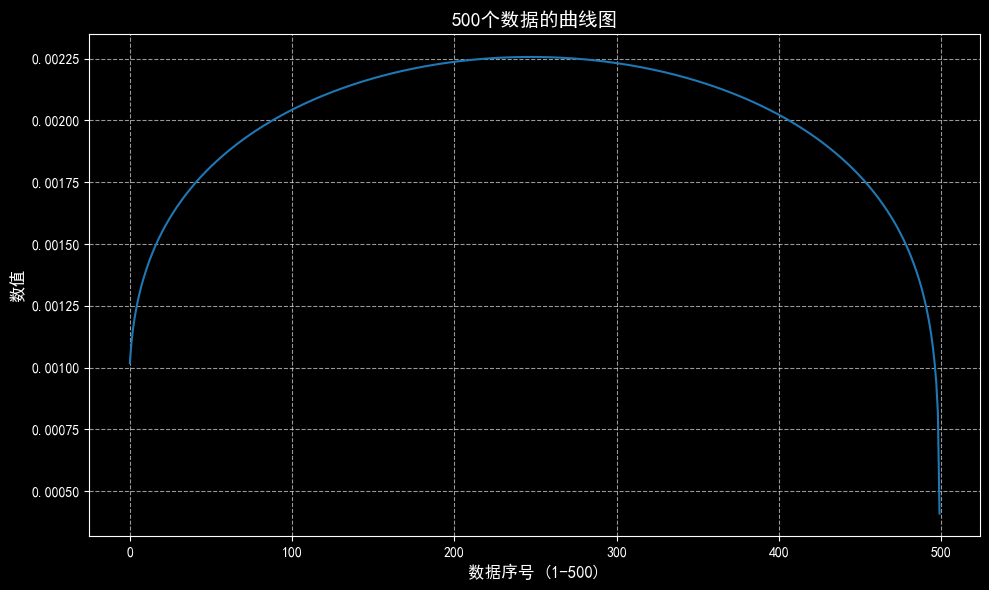

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS', 'Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False


plt.figure(figsize=(10, 6))
plt.plot(p_t, linewidth=1.5, color='#1f77b4')
plt.title('500个数据的曲线图', fontsize=14)
plt.xlabel('数据序号 (1-500)', fontsize=12)
plt.ylabel('数值', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()